# DeepLabV3+ — teljes, javított MRI tumorszegmentációs notebook


## 1. Telepítés és importok

Ebben a részben telepítjük a szükséges csomagokat, majd importáljuk a könyvtárakat.

In [1]:
!pip install -q albumentations==1.4.18 segmentation-models-pytorch timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 18.6 MB/s eta 0:00:00


In [2]:
import os
import gc
import cv2
import json
import math
import time
import random
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Torch version: 2.10.0+cu128
CUDA available: True


## 2. Google Drive csatolása

Ha Colabban dolgoztok, ezt futtassátok. Ha nem kell Drive, ezt a cellát át lehet ugrani.

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception as e:
    IN_COLAB = False
    print('Google Drive mount kihagyva:', e)

Mounted at /content/drive


## 3. Konfiguráció

Itt található minden fontos beállítás egy helyen.

### Mi lett javítva az eredetihez képest?
- **nagyobb input méret** (alapból 320)
- **pretrained encoder**
- **Dice + CrossEntropy kombinált loss**
- **AdamW + CosineAnnealingLR**
- **early stopping**
- **mixed precision**
- **jobb augmentációk**
- **best checkpoint + history mentés**

In [4]:
@dataclass
class CFG:
    # --- Paths ---
    root_path: str = '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train'
    image_dir: str = '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/images'
    mask_dir: str = '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/masks'
    save_dir: str = '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/output_deeplabv3plus_improved'

    # --- Reproducibility ---
    seed: int = 42

    # --- Data ---
    image_size: int = 320
    in_channels: int = 1
    num_classes: int = 2
    val_size: float = 0.20

    # --- Training ---
    batch_size: int = 8
    num_workers: int = 2
    epochs: int = 50
    lr: float = 3e-4
    encoder_lr: float = 1e-4
    decoder_lr: float = 3e-4
    weight_decay: float = 1e-4
    min_lr: float = 1e-6
    patience: int = 10
    grad_clip: float = 1.0
    amp: bool = torch.cuda.is_available()

    # --- Model ---
    model_name: str = 'DeepLabV3Plus'
    encoder_name: str = 'resnet34'
    encoder_weights: str = 'imagenet'

    # --- Training tricks ---
    freeze_encoder_epochs: int = 1
    use_compile: bool = False

    # --- Inference / visualization ---
    threshold: float = 0.5
    num_visualizations: int = 6

    # --- System ---
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'

cfg = CFG()
os.makedirs(cfg.save_dir, exist_ok=True)
print(cfg)

CFG(root_path='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train', image_dir='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/images', mask_dir='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/masks', save_dir='/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/output_deeplabv3plus_improved', seed=42, image_size=320, in_channels=1, num_classes=2, val_size=0.2, batch_size=8, num_workers=2, epochs=50, lr=0.0003, encoder_lr=0.0001, decoder_lr=0.0003, weight_decay=0.0001, min_lr=1e-06, patience=10, grad_clip=1.0, amp=True, model_name='DeepLabV3Plus', encoder_name='resnet34', encoder_weights='imagenet', freeze_encoder_epochs=1, use_compile=False, threshold=0.5, num_visualizations=6, device='cuda')


## 4. Reprodukálhatóság

In [5]:
def seed_everything(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)

## 5. Adatfájlok ellenőrzése és párosítása

Ez a rész biztonságosan összepárosítja a képeket és maszkokat **fájlnév alapján**.

In [6]:
def build_file_pairs(image_dir: str, mask_dir: str):
    image_dir = Path(image_dir)
    mask_dir = Path(mask_dir)

    if not image_dir.exists():
        raise FileNotFoundError(f'Image directory nem található: {image_dir}')
    if not mask_dir.exists():
        raise FileNotFoundError(f'Mask directory nem található: {mask_dir}')

    image_files = [p for p in image_dir.iterdir() if p.is_file()]
    mask_files = [p for p in mask_dir.iterdir() if p.is_file()]

    image_dict = {p.stem: str(p) for p in image_files}
    mask_dict = {p.stem: str(p) for p in mask_files}

    common_keys = sorted(set(image_dict.keys()) & set(mask_dict.keys()))

    print(f'Összes kép: {len(image_dict)}')
    print(f'Összes maszk: {len(mask_dict)}')
    print(f'Közös párok: {len(common_keys)}')

    if len(common_keys) == 0:
        raise RuntimeError('Nincs egyező fájlnév a képek és maszkok között.')

    pairs = [(image_dict[k], mask_dict[k]) for k in common_keys]
    return pairs

pairs = build_file_pairs(cfg.image_dir, cfg.mask_dir)
print('Első 3 pár:')
for x in pairs[:3]:
    print(x)

Összes kép: 3933
Összes maszk: 3933
Közös párok: 3933
Első 3 pár:
('/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/images/brisc2025_train_00001_gl_ax_t1.jpg', '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/masks/brisc2025_train_00001_gl_ax_t1.png')
('/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/images/brisc2025_train_00002_gl_ax_t1.jpg', '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/masks/brisc2025_train_00002_gl_ax_t1.png')
('/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/images/brisc2025_train_00003_gl_ax_t1.jpg', '/content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/masks/brisc2025_train_00003_gl_ax_t1.png')


## 6. Train / validation split

In [7]:
train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=cfg.val_size,
    random_state=cfg.seed,
    shuffle=True,
)

print('Train minták száma:', len(train_pairs))
print('Validation minták száma:', len(val_pairs))

Train minták száma: 3146
Validation minták száma: 787


## 7. Gyors adatelemzés és sanity check

Ez a rész nagyon fontos, mert gyakran a rossz eredmények oka:
- hibás mask
- rossz méret
- rossz intenzitástartomány
- üres vagy elcsúszott mask

In [8]:
def inspect_sample(pair):
    image_path, mask_path = pair
    image = np.array(Image.open(image_path).convert('L'))
    mask = np.array(Image.open(mask_path))

    print('Image path:', image_path)
    print('Mask path:', mask_path)
    print('Image shape:', image.shape, 'dtype:', image.dtype, 'min/max:', image.min(), image.max())
    print('Mask shape:', mask.shape, 'dtype:', mask.dtype, 'unique:', np.unique(mask)[:20])

inspect_sample(train_pairs[0])

Image path: /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/images/brisc2025_train_03706_pi_ax_t1.jpg
Mask path: /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/train/masks/brisc2025_train_03706_pi_ax_t1.png
Image shape: (512, 512) dtype: uint8 min/max: 0 254
Mask shape: (512, 512) dtype: uint8 unique: [  0   1   2   3   4   5   6   7 249 250 251 252 253 254 255]


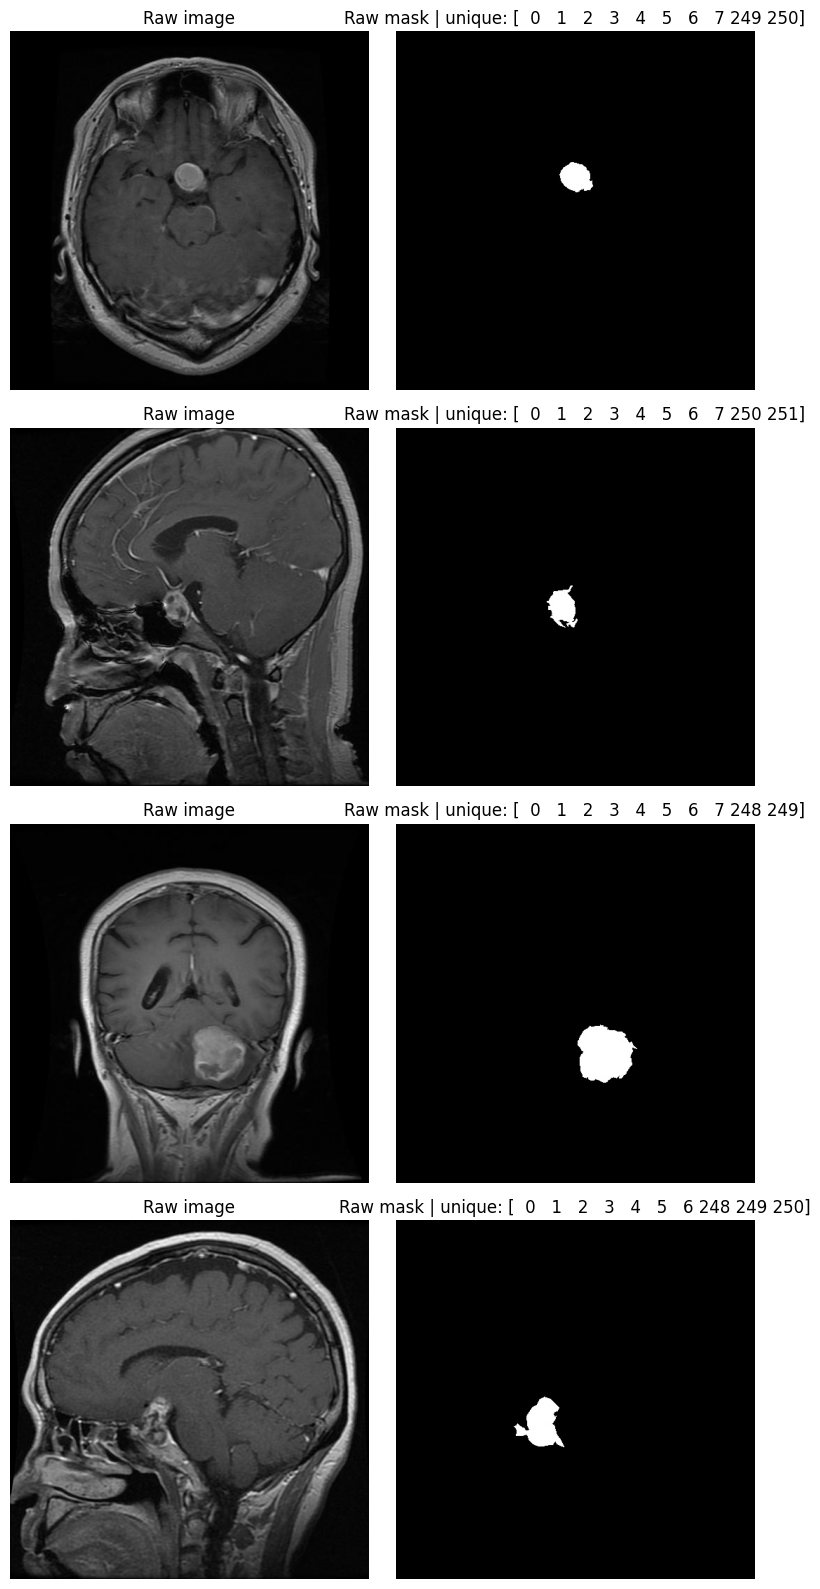

In [9]:
def show_raw_samples(pairs, n=4):
    n = min(n, len(pairs))
    fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        image = np.array(Image.open(pairs[i][0]).convert('L'))
        mask = np.array(Image.open(pairs[i][1]))

        axes[i, 0].imshow(image, cmap='gray')
        axes[i, 0].set_title('Raw image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title(f'Raw mask | unique: {np.unique(mask)[:10]}')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

show_raw_samples(train_pairs, n=4)

## 8. Augmentációk

Az augmentációkat úgy állítottam be, hogy MRI-nél hasznosak legyenek, de ne torzítsák túl agresszívan az adatot.

In [10]:
def get_transforms(train: bool = True, image_size: int = 320):
    mean = (0.5,)
    std = (0.5,)

    if train:
        return A.Compose([
            A.Resize(image_size, image_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.15),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.04,
                scale_limit=0.08,
                rotate_limit=12,
                border_mode=cv2.BORDER_CONSTANT,
                value=0,
                mask_value=0,
                p=0.5,
            ),
            A.OneOf([
                A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                A.MotionBlur(blur_limit=3, p=1.0),
            ], p=0.15),
            A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.2),
            A.Normalize(mean=mean, std=std, max_pixel_value=255.0),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(image_size, image_size),
            A.Normalize(mean=mean, std=std, max_pixel_value=255.0),
            ToTensorV2(),
        ])

## 9. Dataset osztály

In [11]:
class BrainMRISegDataset(Dataset):
    def __init__(self, pairs, transforms=None, num_classes=2):
        self.pairs = pairs
        self.transforms = transforms
        self.num_classes = num_classes

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image_path, mask_path = self.pairs[idx]

        image = np.array(Image.open(image_path).convert('L'))
        mask = np.array(Image.open(mask_path))

        if self.num_classes == 2:
            mask = (mask > 0).astype(np.uint8)
        else:
            mask = mask.astype(np.uint8)

        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        return image.float(), mask.long()

## 10. DataLoaderek

In [12]:
train_ds = BrainMRISegDataset(
    train_pairs,
    transforms=get_transforms(train=True, image_size=cfg.image_size),
    num_classes=cfg.num_classes,
)

val_ds = BrainMRISegDataset(
    val_pairs,
    transforms=get_transforms(train=False, image_size=cfg.image_size),
    num_classes=cfg.num_classes,
)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=False,
)

print('Train batches:', len(train_loader))
print('Val batches:', len(val_loader))

Train batches: 394
Val batches: 99


## 11. Batch sanity check

In [13]:
images, masks = next(iter(train_loader))
print('Images shape:', images.shape)
print('Masks shape:', masks.shape)
print('Image dtype:', images.dtype)
print('Mask dtype:', masks.dtype)
print('Mask unique values:', torch.unique(masks))

Images shape: torch.Size([8, 1, 320, 320])
Masks shape: torch.Size([8, 320, 320])
Image dtype: torch.float32
Mask dtype: torch.int64
Mask unique values: tensor([0, 1])


## 12. Modell

### Fontos javítások
- **encoder_weights='imagenet'** → jobb feature extraction
- **1 csatornás input** → grayscale MRI-hoz igazítva

In [14]:
def build_model(cfg):
    model = smp.DeepLabV3Plus(
        encoder_name=cfg.encoder_name,
        encoder_weights=cfg.encoder_weights,
        in_channels=cfg.in_channels,
        classes=cfg.num_classes,
        activation=None,
    )
    return model

model = build_model(cfg).to(cfg.device)
print(model.__class__.__name__, 'ready on', cfg.device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

DeepLabV3Plus ready on cuda


## 13. Loss függvények

A sima CrossEntropy sokszor kevés szegmentációnál. Ezért itt **CrossEntropy + DiceLoss** kombinációt használunk.

In [15]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6, ignore_background=True):
        super().__init__()
        self.smooth = smooth
        self.ignore_background = ignore_background

    def forward(self, logits, targets):
        num_classes = logits.shape[1]
        probs = torch.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, num_classes=num_classes).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_oh, dims)
        cardinality = torch.sum(probs + targets_oh, dims)
        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)

        if self.ignore_background and num_classes > 1:
            dice = dice[1:]

        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

criterion = CombinedLoss(ce_weight=0.5, dice_weight=0.5)

## 14. Metrikák

In [16]:
@torch.no_grad()
def compute_batch_metrics(logits, targets, num_classes=2, eps=1e-6):
    preds = torch.argmax(logits, dim=1)

    dices = []
    ious = []

    for cls in range(1, num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        dice = (2 * intersection + eps) / (pred_cls.sum() + target_cls.sum() + eps)
        iou = (intersection + eps) / (pred_cls.sum() + target_cls.sum() - intersection + eps)

        dices.append(dice.item())
        ious.append(iou.item())

    mean_dice = float(np.mean(dices)) if len(dices) > 0 else 0.0
    mean_iou = float(np.mean(ious)) if len(ious) > 0 else 0.0
    return mean_dice, mean_iou

## 15. Optimizer, scheduler, scaler

In [17]:
def make_optimizer(model, cfg):
    encoder_params = list(model.encoder.parameters())
    decoder_params = [p for n, p in model.named_parameters() if not n.startswith('encoder.')]

    optimizer = torch.optim.AdamW(
        [
            {'params': encoder_params, 'lr': cfg.encoder_lr},
            {'params': decoder_params, 'lr': cfg.decoder_lr},
        ],
        weight_decay=cfg.weight_decay,
    )
    return optimizer

optimizer = make_optimizer(model, cfg)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cfg.epochs,
    eta_min=cfg.min_lr,
)
scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp)

print('Optimizer és scheduler kész.')

Optimizer és scheduler kész.


/tmp/ipykernel_832/4016046550.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp)


## 16. Freeze / unfreeze helper

Ez egy egyszerű fine-tuning trükk: az első epoch(ok)ban lefagyasztjuk az encodert, majd utána felengedjük.

In [18]:
def set_encoder_trainable(model, trainable=True):
    for p in model.encoder.parameters():
        p.requires_grad = trainable

## 17. Train és validation loop

In [19]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler, grad_clip=1.0):
    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    pbar = tqdm(loader, total=len(loader), desc='Train', leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):
            logits = model(images)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()

        if grad_clip is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()

        dice, iou = compute_batch_metrics(logits.detach(), masks, num_classes=cfg.num_classes)

        running_loss += loss.item()
        running_dice += dice
        running_iou += iou

        pbar.set_postfix(loss=f'{running_loss/(pbar.n+1):.4f}', dice=f'{running_dice/(pbar.n+1):.4f}')

    n = len(loader)
    return running_loss / n, running_dice / n, running_iou / n


@torch.no_grad()
def valid_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    pbar = tqdm(loader, total=len(loader), desc='Valid', leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)
        dice, iou = compute_batch_metrics(logits, masks, num_classes=cfg.num_classes)

        running_loss += loss.item()
        running_dice += dice
        running_iou += iou

    n = len(loader)
    return running_loss / n, running_dice / n, running_iou / n

## 18. Early stopping helper

In [20]:
class EarlyStopping:
    def __init__(self, patience=10, mode='max'):
        self.patience = patience
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        if self.best_score is None:
            self.best_score = score
            return True

        improved = score > self.best_score if self.mode == 'max' else score < self.best_score

        if improved:
            self.best_score = score
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False

## 19. Training főciklus

In [21]:
history = {
    'train_loss': [], 'train_dice': [], 'train_iou': [],
    'val_loss': [], 'val_dice': [], 'val_iou': [],
    'lr_encoder': [], 'lr_decoder': [],
}

best_dice = -np.inf
best_model_path = os.path.join(cfg.save_dir, 'best_model.pt')
last_model_path = os.path.join(cfg.save_dir, 'last_model.pt')
history_path = os.path.join(cfg.save_dir, 'history.json')
config_path = os.path.join(cfg.save_dir, 'config.json')

with open(config_path, 'w') as f:
    json.dump(asdict(cfg), f, indent=2)

early_stopper = EarlyStopping(patience=cfg.patience, mode='max')

for epoch in range(cfg.epochs):
    start_time = time.time()

    if epoch < cfg.freeze_encoder_epochs:
        set_encoder_trainable(model, False)
        freeze_status = 'FROZEN'
    else:
        set_encoder_trainable(model, True)
        freeze_status = 'UNFROZEN'

    train_loss, train_dice, train_iou = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=cfg.device,
        scaler=scaler,
        grad_clip=cfg.grad_clip,
    )

    val_loss, val_dice, val_iou = valid_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=cfg.device,
    )

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['train_iou'].append(train_iou)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)
    history['lr_encoder'].append(optimizer.param_groups[0]['lr'])
    history['lr_decoder'].append(optimizer.param_groups[1]['lr'])

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1:02d}/{cfg.epochs}] | Encoder: {freeze_status} | "
        f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | Train IoU: {train_iou:.4f} || "
        f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f} || "
        f"Time: {elapsed:.1f}s"
    )

    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_dice': best_dice,
        'config': asdict(cfg),
        'history': history,
    }
    torch.save(checkpoint, last_model_path)

    is_best = early_stopper.step(val_dice)
    if is_best and val_dice > best_dice:
        best_dice = val_dice
        checkpoint['best_dice'] = best_dice
        torch.save(checkpoint, best_model_path)
        print(f'>>> Új legjobb modell mentve! Best Dice: {best_dice:.4f}')

    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)

    if early_stopper.should_stop:
        print(f'Early stopping aktiválva a(z) {epoch+1}. epoch után.')
        break

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('Training kész.')
print('Best Dice:', best_dice)
print('Best model:', best_model_path)
print('Last model:', last_model_path)

Train:   0%|          | 0/394 [00:00<?, ?it/s]

/tmp/ipykernel_832/2996285006.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


Valid:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch [01/50] | Encoder: FROZEN | Train Loss: 0.3022 | Train Dice: 0.5550 | Train IoU: 0.4001 || Val Loss: 0.2251 | Val Dice: 0.6243 | Val IoU: 0.4649 || Time: 1311.9s
>>> Új legjobb modell mentve! Best Dice: 0.6243


Train:   0%|          | 0/394 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch [49/50] | Encoder: UNFROZEN | Train Loss: 0.0622 | Train Dice: 0.8961 | Train IoU: 0.8128 || Val Loss: 0.0780 | Val Dice: 0.8705 | Val IoU: 0.7736 || Time: 44.5s


Train:   0%|          | 0/394 [00:00<?, ?it/s]

Valid:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch [50/50] | Encoder: UNFROZEN | Train Loss: 0.0627 | Train Dice: 0.8951 | Train IoU: 0.8112 || Val Loss: 0.0781 | Val Dice: 0.8705 | Val IoU: 0.7736 || Time: 39.7s
Training kész.
Best Dice: 0.8707508113649156
Best model: /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/output_deeplabv3plus_improved/best_model.pt
Last model: /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/output_deeplabv3plus_improved/last_model.pt


## 20. Training history kirajzolása

Training curves mentve: /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/output_deeplabv3plus_improved/training_curves.png


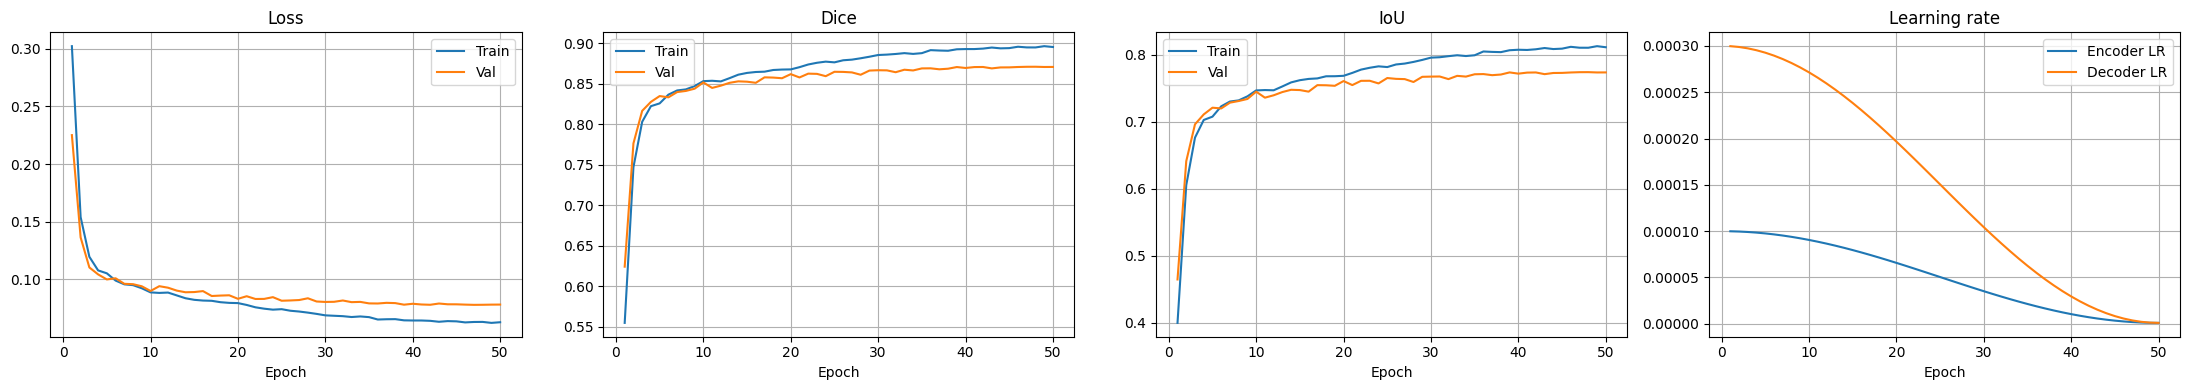

In [22]:
def plot_training_history(history, save_dir=None):
    epochs = np.arange(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'], label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(epochs, history['train_dice'], label='Train')
    axes[1].plot(epochs, history['val_dice'], label='Val')
    axes[1].set_title('Dice')
    axes[1].set_xlabel('Epoch')
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(epochs, history['train_iou'], label='Train')
    axes[2].plot(epochs, history['val_iou'], label='Val')
    axes[2].set_title('IoU')
    axes[2].set_xlabel('Epoch')
    axes[2].grid(True)
    axes[2].legend()

    axes[3].plot(epochs, history['lr_encoder'], label='Encoder LR')
    axes[3].plot(epochs, history['lr_decoder'], label='Decoder LR')
    axes[3].set_title('Learning rate')
    axes[3].set_xlabel('Epoch')
    axes[3].grid(True)
    axes[3].legend()

    plt.tight_layout()

    if save_dir is not None:
        save_path = os.path.join(save_dir, 'training_curves.png')
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print('Training curves mentve:', save_path)

    plt.show()

plot_training_history(history, cfg.save_dir)

## 21. Best checkpoint visszatöltése

In [23]:
checkpoint = torch.load(best_model_path, map_location=cfg.device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print('Best checkpoint betöltve innen:', best_model_path)
print('Checkpoint best_dice:', checkpoint.get('best_dice', None))

Best checkpoint betöltve innen: /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/output_deeplabv3plus_improved/best_model.pt
Checkpoint best_dice: 0.8707508113649156


## 22. Predikciós helper függvények

In [24]:
@torch.no_grad()
def predict_mask(model, image_tensor, device):
    model.eval()
    x = image_tensor.unsqueeze(0).to(device)
    logits = model(x)
    pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    return pred


def denormalize_grayscale(img_tensor):
    img = img_tensor.squeeze(0).cpu().numpy()
    img = img * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    return img


def make_overlay(image_gray, pred_mask, alpha=0.35):
    image_rgb = np.stack([image_gray, image_gray, image_gray], axis=-1)
    overlay = image_rgb.copy()
    red_mask = np.zeros_like(image_rgb)
    red_mask[..., 0] = 1.0
    region = pred_mask > 0
    overlay[region] = (1 - alpha) * overlay[region] + alpha * red_mask[region]
    return overlay

## 23. Vizualizációk a validation halmazon

In [ ]:
def visualize_predictions(model, dataset, device, num_samples=6, save_dir=None):
    indices = np.linspace(0, len(dataset) - 1, min(num_samples, len(dataset)), dtype=int)
    fig, axes = plt.subplots(len(indices), 4, figsize=(16, 4 * len(indices)))

    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):
        image_tensor, mask_tensor = dataset[idx]
        pred_mask = predict_mask(model, image_tensor, device)
        image_gray = denormalize_grayscale(image_tensor)
        true_mask = mask_tensor.cpu().numpy()
        overlay = make_overlay(image_gray, pred_mask)

        axes[row, 0].imshow(image_gray, cmap='gray')
        axes[row, 0].set_title('Original')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(true_mask, cmap='gray')
        axes[row, 1].set_title('Ground truth')
        axes[row, 1].axis('off')

        axes[row, 2].imshow(pred_mask, cmap='gray')
        axes[row, 2].set_title('Prediction')
        axes[row, 2].axis('off')

        axes[row, 3].imshow(overlay)
        axes[row, 3].set_title('Overlay')
        axes[row, 3].axis('off')

    plt.tight_layout()

    if save_dir is not None:
        save_path = os.path.join(save_dir, 'prediction_examples.png')
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print('Prediction példa mentve:', save_path)

    plt.show()

visualize_predictions(model, val_ds, cfg.device, num_samples=cfg.num_visualizations, save_dir=cfg.save_dir)

## 24. Sample-szintű IoU számítás

In [ ]:
@torch.no_grad()
def compute_sample_iou(pred_mask, true_mask, eps=1e-6):
    pred = (pred_mask > 0).astype(np.uint8)
    true = (true_mask > 0).astype(np.uint8)

    intersection = np.logical_and(pred, true).sum()
    union = np.logical_or(pred, true).sum()
    return float((intersection + eps) / (union + eps))

## 25. Tumortípus felismerése fájlnévből / elérési útból

In [ ]:
def infer_tumor_type_from_path(image_path: str):
    p = image_path.lower()
    if 'glioma' in p:
        return 'Glioma'
    elif 'meningioma' in p:
        return 'Meningioma'
    elif 'pituitary' in p or 'hypophysis' in p:
        return 'Pituitary'
    else:
        return 'Unknown'

## 26. Kiértékelés tumortípusonként

In [ ]:
@torch.no_grad()
def evaluate_by_tumor_type(model, dataset, device, model_name='DeepLabV3+'):
    per_type_ious = {
        'Glioma': [],
        'Meningioma': [],
        'Pituitary': [],
        'Unknown': [],
    }

    for idx in tqdm(range(len(dataset)), desc='Tumor-type evaluation'):
        image_tensor, mask_tensor = dataset[idx]
        pred_mask = predict_mask(model, image_tensor, device)
        true_mask = mask_tensor.cpu().numpy()

        image_path, _ = dataset.pairs[idx]
        tumor_type = infer_tumor_type_from_path(image_path)
        iou = compute_sample_iou(pred_mask, true_mask)
        per_type_ious[tumor_type].append(iou)

    def safe_mean(values):
        return float(np.mean(values)) if len(values) > 0 else np.nan

    results = pd.DataFrame([{
        'Model': model_name,
        'mIoU Glioma': safe_mean(per_type_ious['Glioma']),
        'mIoU Meningioma': safe_mean(per_type_ious['Meningioma']),
        'mIoU Pituitary': safe_mean(per_type_ious['Pituitary']),
        'mIoU Unknown': safe_mean(per_type_ious['Unknown']),
        'Weighted mIoU (known)': safe_mean(
            per_type_ious['Glioma'] + per_type_ious['Meningioma'] + per_type_ious['Pituitary']
        )
    }])

    return results, per_type_ious

results_df, per_type_ious = evaluate_by_tumor_type(
    model=model,
    dataset=val_ds,
    device=cfg.device,
    model_name=cfg.model_name,
)

results_df

## 27. Eredménytábla mentése

In [ ]:
def display_results_table(df, save_dir=None):
    df_rounded = df.copy()
    for col in df_rounded.columns:
        if col != 'Model':
            df_rounded[col] = df_rounded[col].map(lambda x: round(x, 4) if pd.notnull(x) else x)

    print(df_rounded)

    if save_dir is not None:
        csv_path = os.path.join(save_dir, 'miou_results.csv')
        df_rounded.to_csv(csv_path, index=False)
        print('Táblázat mentve:', csv_path)

    return df_rounded

display_results_table(results_df, save_dir=cfg.save_dir)

## 28. Opcionális: teljes validation halmaz összesített métrikája

In [ ]:
@torch.no_grad()
def evaluate_full_loader(model, loader, device, criterion=None):
    model.eval()
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0

    for images, masks in tqdm(loader, desc='Full validation evaluation'):
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        if criterion is not None:
            total_loss += criterion(logits, masks).item()

        dice, iou = compute_batch_metrics(logits, masks, num_classes=cfg.num_classes)
        total_dice += dice
        total_iou += iou

    n = len(loader)
    return {
        'loss': total_loss / n if criterion is not None else None,
        'dice': total_dice / n,
        'iou': total_iou / n,
    }

final_metrics = evaluate_full_loader(model, val_loader, cfg.device, criterion)
print(final_metrics)

Full validation evaluation:   0%|          | 0/99 [00:00<?, ?it/s]

{'loss': 0.07787090528643492, 'dice': 0.8707508113649156, 'iou': 0.7740349188597515}


## 29. Végső összefoglaló cella

Ezt a cellát akkor érdemes futtatni, amikor minden elkészült.

In [ ]:
print('=' * 80)
print('DeepLabV3+ improved pipeline kész.')
print('Mentési mappa:', cfg.save_dir)
print('Best model:', best_model_path)
print('History file:', history_path)
print('Config file:', config_path)
print('Final validation metrics:', final_metrics)
print('=' * 80)

DeepLabV3+ improved pipeline kész.
Mentési mappa: /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/output_deeplabv3plus_improved
Best model: /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/output_deeplabv3plus_improved/best_model.pt
History file: /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/output_deeplabv3plus_improved/history.json
Config file: /content/drive/MyDrive/Brain MRI/brisc2025/segmentation_task/output_deeplabv3plus_improved/config.json
Final validation metrics: {'loss': 0.07787090528643492, 'dice': 0.8707508113649156, 'iou': 0.7740349188597515}
